<font color=green>

## Home Task: Implement K-means algorithm

</font>

In [93]:
import numpy as np
import matplotlib.pyplot as plt

<font color=green>

### Data

</font>

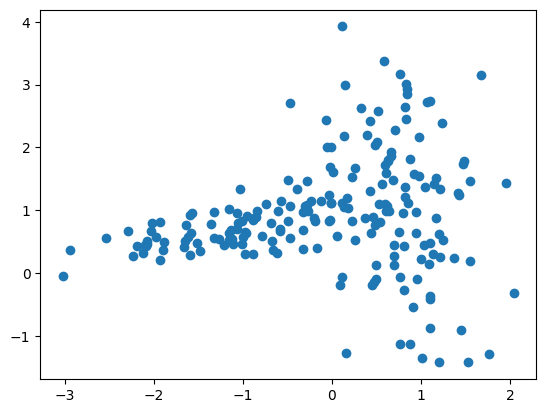

In [94]:
from sklearn.datasets import make_classification

Xc_2, _ = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=0,
    n_clusters_per_class=1,
    class_sep=0.8,
)

points = Xc_2
colors = np.array(['green', 'orange', 'blue', 'red'])

plt.scatter(points[:, 0], points[:, 1])
plt.show()

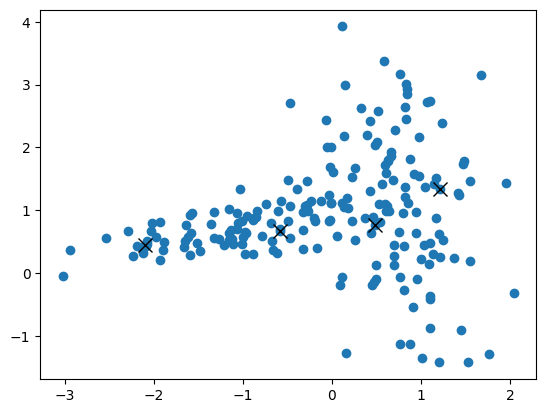

In [95]:
def init_centroids(amount=1, points=None, seed=1):
    np.random.seed(seed)
    return points[np.random.choice(len(points), amount)]

def compute_distances(samples, centroids):
    return np.array([np.apply_along_axis(np.linalg.norm, 1, samples - c) for c in centroids])

def compute_closest_centroids(centroids):
    all_distances = compute_distances(points, centroids)
    return np.apply_along_axis(np.argmin, 0, all_distances)

centroids = init_centroids(4, points=points)
plt.scatter(points[:, 0], points[:, 1])
for i, c in enumerate(centroids):
    plt.plot(c[0], c[1], marker='x', color='black', markersize=10)
plt.show()

In [96]:
def J(centroids, closest_centroids):
    all_dist = []
    for c_index in set(closest_centroids):
        assigned = points[np.where(closest_centroids == c_index)]
        all_dist.append(np.sum(compute_distances(assigned, [centroids[c_index]])))
    return 1 / len(closest_centroids) * np.sum(all_dist)

def compute_means(centroids, closest_centroids):
    new_centroids = []
    for i in range(len(centroids)):
        if i not in closest_centroids:
            new_centroids.append(centroids[i])
        else:
            new_centroids.append(np.mean(points[np.where(closest_centroids == i)], axis=0))
    return new_centroids

def run_k_means(centroids):
    is_first_time = True
    J_hist = []
    is_to_continue = True
    while is_to_continue:
        closest_centroids = compute_closest_centroids(centroids)
        centroids = compute_means(centroids, closest_centroids)
        new_J = J(centroids, closest_centroids)
        if is_first_time:
            J_hist.append(new_J)
            is_first_time = False
            continue
        if J_hist[-1] == new_J:
            is_to_continue = False
        else:
            J_hist.append(new_J)
    return centroids, closest_centroids, J_hist

In [97]:
K = 4
best_centroids = None
best_labels = None
best_cost = float('inf')

for _ in range(100):
    centroids = init_centroids(amount=K, points=points, seed=None)
    centroids, closest_centroids, J_hist = run_k_means(centroids)
    if J_hist[-1] < best_cost:
        best_centroids = centroids
        best_labels = closest_centroids
        best_cost = J_hist[-1]

print(f'Best cost J = {best_cost:.4f}')

Best cost J = 0.5997


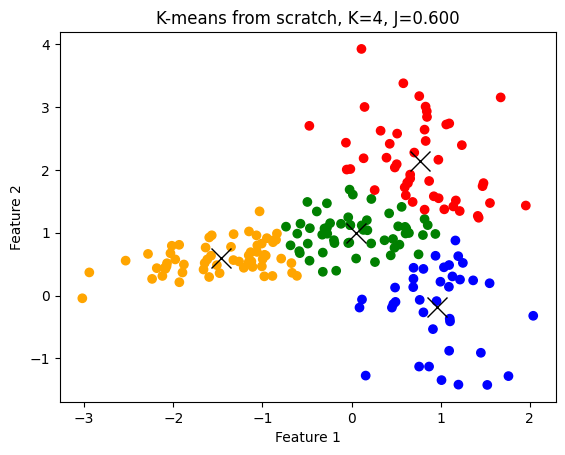

In [98]:
plt.figure()
plt.scatter(points[:, 0], points[:, 1], c=colors[best_labels])
for i, c in enumerate(best_centroids):
    plt.plot(c[0], c[1], marker='x', color='black', markersize=14)
plt.title(f'K-means from scratch, K={K}, J={best_cost:.3f}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

K=1  J=1.2589
K=2  J=0.8833
K=3  J=0.7048
K=4  J=0.5997
K=5  J=0.5181
K=6  J=0.4597
K=7  J=0.4155
K=8  J=0.3893


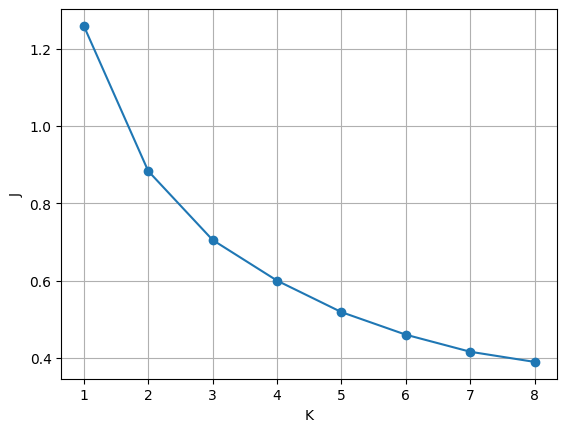

In [99]:
elbow_costs = []
K_range = range(1, 9)

for k in K_range:
    best_cost_k = float('inf')
    for _ in range(100):
        centroids = init_centroids(amount=k, points=points, seed=None)
        centroids, closest_centroids, J_hist = run_k_means(centroids)
        if J_hist[-1] < best_cost_k:
            best_cost_k = J_hist[-1]
    elbow_costs.append(best_cost_k)
    print(f'K={k}  J={best_cost_k:.4f}')

plt.plot(list(K_range), elbow_costs, marker='o')
plt.xlabel('K')
plt.ylabel('J')
plt.grid(True)
plt.show()

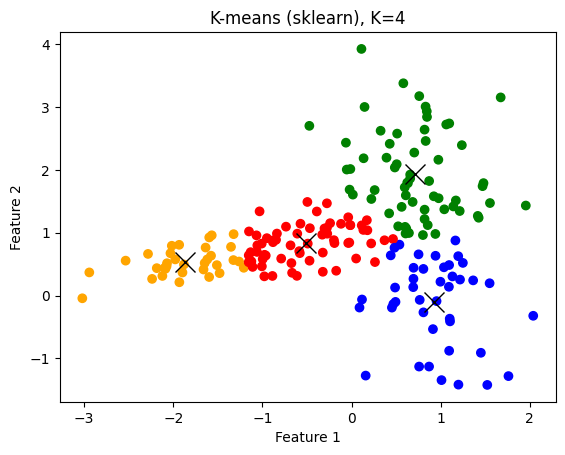

In [100]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=0, n_init='auto').fit(points)
sklearn_centroids = kmeans.cluster_centers_
sklearn_labels = kmeans.labels_

plt.figure()
plt.scatter(points[:, 0], points[:, 1], c=colors[sklearn_labels])
for i, c in enumerate(sklearn_centroids):
    plt.plot(c[0], c[1], marker='x', color='black', markersize=14)
plt.title('K-means (sklearn), K=4')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()